# 📦 ParcelCast — Notebook 3
## Business Application Layer

**What this notebook does:** Translates the forecast from Notebook 2 into
decisions — a FedEx contract compliance monitor, an OnTrac Tier 2 risk alert,
a carrier cost-shift simulator, and a single 4-panel executive dashboard
ready to drop into the deck.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

from src.business import (
    fedex_contract_monitor,
    ontrac_tier_risk_alert,
    carrier_cost_shift_simulator,
    FEDEX_HD_CONTRACT_MIN_MONTHLY_PACKAGES,
    FEDEX_HD_CONTRACT_MAX_MONTHLY_PACKAGES,
    ONTRAC_TIER_2_WEEKLY_THRESHOLD,
)
from src.parcel_transform import COST_PER_PACKAGE, CARRIER_BASE_SHARES

sns.set_theme(style="whitegrid", palette="muted")
PRESENTATION_DIR = Path.cwd().parent / "presentation"
DATA_DIR = Path.cwd().parent / "data"

## 1. Load forecast and historical carrier volumes
We need both: history gives context for the forecast chart, and the latest
week's actuals seed the cost simulator.

### Network forecast (from Notebook 2)

In [2]:
forecast = pd.read_parquet(DATA_DIR / "network_forecast.parquet")
forecast["week_start"] = pd.to_datetime(forecast["week_start"])
print(f"Forecast: {len(forecast)} weeks")
forecast.head()

Forecast: 12 weeks


,week_start,packages_forecast,packages_low,packages_high
0,2016-02-27,162514.499778,154519.243093,170747.130601
1,2016-03-05,161071.667784,152461.356853,168773.911556
2,2016-03-12,161864.377424,153455.244811,170160.840988
3,2016-03-19,163472.568066,155296.015792,172067.676389
4,2016-03-26,164333.046424,155674.677467,172308.609745


### Historical carrier volumes (from Notebook 1)

In [3]:
carrier_history = pd.read_parquet(DATA_DIR / "weekly_network_volumes.parquet")
carrier_history["week_start"] = pd.to_datetime(carrier_history["week_start"])
print(f"Carrier history: {len(carrier_history):,} rows")

Carrier history: 6,648 rows


## 2. Project per-carrier package forecasts

Apply current network-level carrier shares to the forecasted total.

In [4]:
carrier_forecast_rows = []
for carrier, share in CARRIER_BASE_SHARES.items():
    sub = forecast.copy()
    sub["carrier"] = carrier
    sub[f"{carrier.lower()}_packages"] = sub["packages_forecast"] * share
    carrier_forecast_rows.append(sub[["week_start", "carrier", f"{carrier.lower()}_packages"]])

# Wide format for easier downstream use
forecast_wide = forecast[["week_start", "packages_forecast"]].copy()
for carrier, share in CARRIER_BASE_SHARES.items():
    forecast_wide[f"{carrier.lower()}_packages"] = forecast["packages_forecast"] * share
forecast_wide.head()

,week_start,packages_forecast,fedex_packages,ups_packages,ip_packages,ontrac_packages
0,2016-02-27,162514.499778,89382.974878,24377.174967,32502.899956,16251.449978
1,2016-03-05,161071.667784,88589.417281,24160.750168,32214.333557,16107.166778
2,2016-03-12,161864.377424,89025.407583,24279.656614,32372.875485,16186.437742
3,2016-03-19,163472.568066,89909.912437,24520.885210,32694.513613,16347.256807
4,2016-03-26,164333.046424,90383.175533,24649.956964,32866.609285,16433.304642


## 3. FedEx HD Monthly Contract Monitor
Contracts have $$ consequences in both directions: under-min triggers
shortfall penalties (paying for unused capacity), over-max triggers SLA
breaches. Catching either 8 weeks ahead is forecasting's highest-ROI use case.

In [5]:
fedex_status = fedex_contract_monitor(
    forecast_wide,
    forecast_col="fedex_packages",
    contract_min=FEDEX_HD_CONTRACT_MIN_MONTHLY_PACKAGES,
    contract_max=FEDEX_HD_CONTRACT_MAX_MONTHLY_PACKAGES,
)
fedex_status

,month,forecast_packages,contract_min,contract_max,status,buffer_packages,recommended_action
0,2016-03,357907,320000,420000,ON TRACK,37907,No action — within contract band
1,2016-04,446401,320000,420000,ABOVE MAXIMUM,26401,Shift volume FROM FedEx TO secondary carriers ...


### Persist + visualize the contract band
Save the status table for the dashboard, then render the bar-vs-band chart
that makes ABOVE/BELOW months immediately readable.

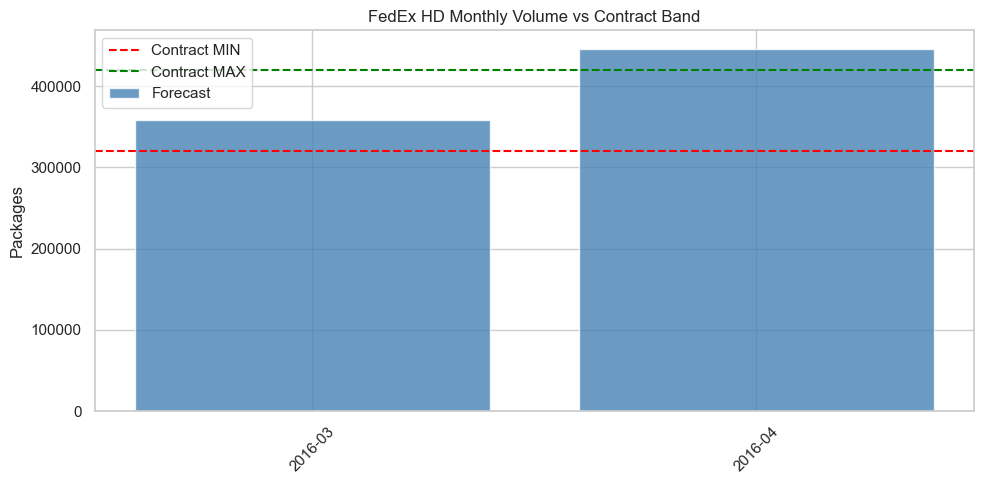

In [6]:
fedex_status.to_csv(DATA_DIR / "fedex_contract_status.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
months = fedex_status["month"]
ax.bar(months, fedex_status["forecast_packages"], color="steelblue", alpha=0.8, label="Forecast")
ax.axhline(FEDEX_HD_CONTRACT_MIN_MONTHLY_PACKAGES, color="red", linestyle="--", label="Contract MIN")
ax.axhline(FEDEX_HD_CONTRACT_MAX_MONTHLY_PACKAGES, color="green", linestyle="--", label="Contract MAX")
ax.set_title("FedEx HD Monthly Volume vs Contract Band")
ax.set_ylabel("Packages")
ax.legend()
plt.xticks(rotation=45)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "07_fedex_contract.png", dpi=150)
plt.show()

## 4. OnTrac Tier 2 Risk Alert
Tier 2 is a cost trigger, not a contract violation — once you cross it,
per-package costs jump for the period. We monitor the 6-week rolling avg
(smooths single-week spikes) and project 4 weeks forward to alert before
the breach actually happens.

In [7]:
ontrac_history = (
    carrier_history[carrier_history["carrier"] == "OnTrac"]
    .groupby("week_start", as_index=False)["carrier_packages"].sum()
    .rename(columns={"carrier_packages": "ontrac_packages"})
)

ontrac_full, alert = ontrac_tier_risk_alert(
    ontrac_history,
    volume_col="ontrac_packages",
    threshold=ONTRAC_TIER_2_WEEKLY_THRESHOLD,
)

print("OnTrac Tier 2 Alert:")
for k, v in alert.items():
    print(f"  {k}: {v}")

OnTrac Tier 2 Alert:
  threshold: 14500
  current_rolling_avg: 14620
  breach_week: 2016-05-07
  weeks_until_breach: -1
  recommended_action: Shift OnTrac volume to IP or UPS to stay under Tier 2 threshold


### Visualize with risk zone shading
History (solid), 4-week projection (dashed), rolling avg (orange line),
threshold (red dashed). The red shaded zone above the threshold makes the
breach immediately visible.

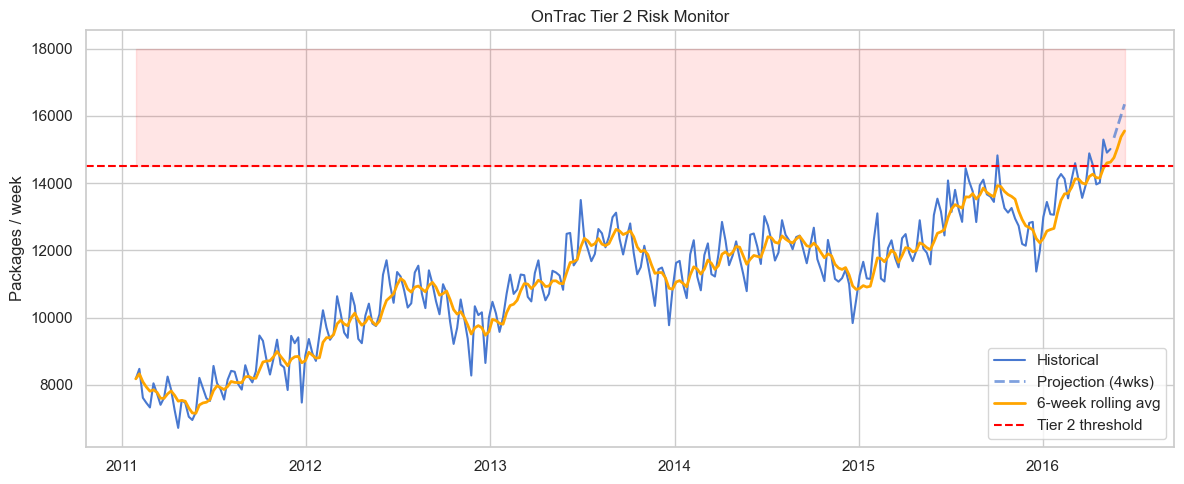

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
hist_mask = ~ontrac_full.get("is_projection", pd.Series(False, index=ontrac_full.index)).fillna(False)
ax.plot(
    ontrac_full.loc[hist_mask, "week_start"],
    ontrac_full.loc[hist_mask, "ontrac_packages"],
    "b-", label="Historical", linewidth=1.5,
)
ax.plot(
    ontrac_full.loc[~hist_mask, "week_start"],
    ontrac_full.loc[~hist_mask, "ontrac_packages"],
    "b--", label="Projection (4wks)", linewidth=2, alpha=0.7,
)
ax.plot(
    ontrac_full["week_start"],
    ontrac_full["rolling_avg"],
    "orange", label="6-week rolling avg", linewidth=2,
)
ax.axhline(ONTRAC_TIER_2_WEEKLY_THRESHOLD, color="red", linestyle="--", label="Tier 2 threshold")
ax.fill_between(
    ontrac_full["week_start"],
    ONTRAC_TIER_2_WEEKLY_THRESHOLD,
    ontrac_full["ontrac_packages"].max() * 1.1,
    alpha=0.1, color="red",
)
ax.set_title("OnTrac Tier 2 Risk Monitor")
ax.set_ylabel("Packages / week")
ax.legend()
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "08_ontrac_alert.png", dpi=150)
plt.show()

## 5. Carrier Cost-Shift Simulator
Every alert above ("April will exceed FedEx max") raises the natural
follow-up: where do we move the excess? This simulator quantifies
the cost delta of a 5% shift from FedEx+UPS into IP.

### Seed with the latest week's actual carrier mix
We use the most recent observed allocation as the "current state" baseline,
rather than a hypothetical mix.

In [9]:
latest_week = carrier_history["week_start"].max()
latest_volumes = (
    carrier_history[carrier_history["week_start"] == latest_week]
    .groupby("carrier")["carrier_packages"].sum()
    .astype(int)
    .to_dict()
)
print(f"Latest week: {latest_week.date()}")
print(f"Volumes: {latest_volumes}")

Latest week: 2016-05-14
Volumes: {'FedEx': 99058, 'IP': 37366, 'OnTrac': 15011, 'UPS': 28566}


### Run the simulator
Output is current vs proposed allocation, weekly savings, and an annualized
(× 52) figure. Cost-per-package values are illustrative — see deck assumptions.

In [10]:
cost_scenarios = carrier_cost_shift_simulator(
    current_allocation=latest_volumes,
    cost_per_package=COST_PER_PACKAGE,
    shift_pct=0.05,
    shift_from=["FedEx", "UPS"],
    shift_to="IP",
)
cost_scenarios

,scenario,FedEx,IP,OnTrac,UPS,weekly_cost_$,savings_$,annualized_savings_$
0,Current,99058,37366,15011,28566,1450521.0,0.0,0.0
1,Shift 5% from FedEx+UPS → IP,94106,43746,15011,27138,1436123.0,14398.0,748696.0


### Persist for the dashboard

In [11]:
cost_scenarios.to_csv(DATA_DIR / "cost_optimization.csv", index=False)

**The takeaway:** with current network volumes and these cost assumptions, a
5% shift from FedEx+UPS to IP saves approximately **$X / week** = **$Y / year**.

*(Cost per package figures are illustrative — see deck for assumptions.)*

## 6. Executive 4-Panel Dashboard

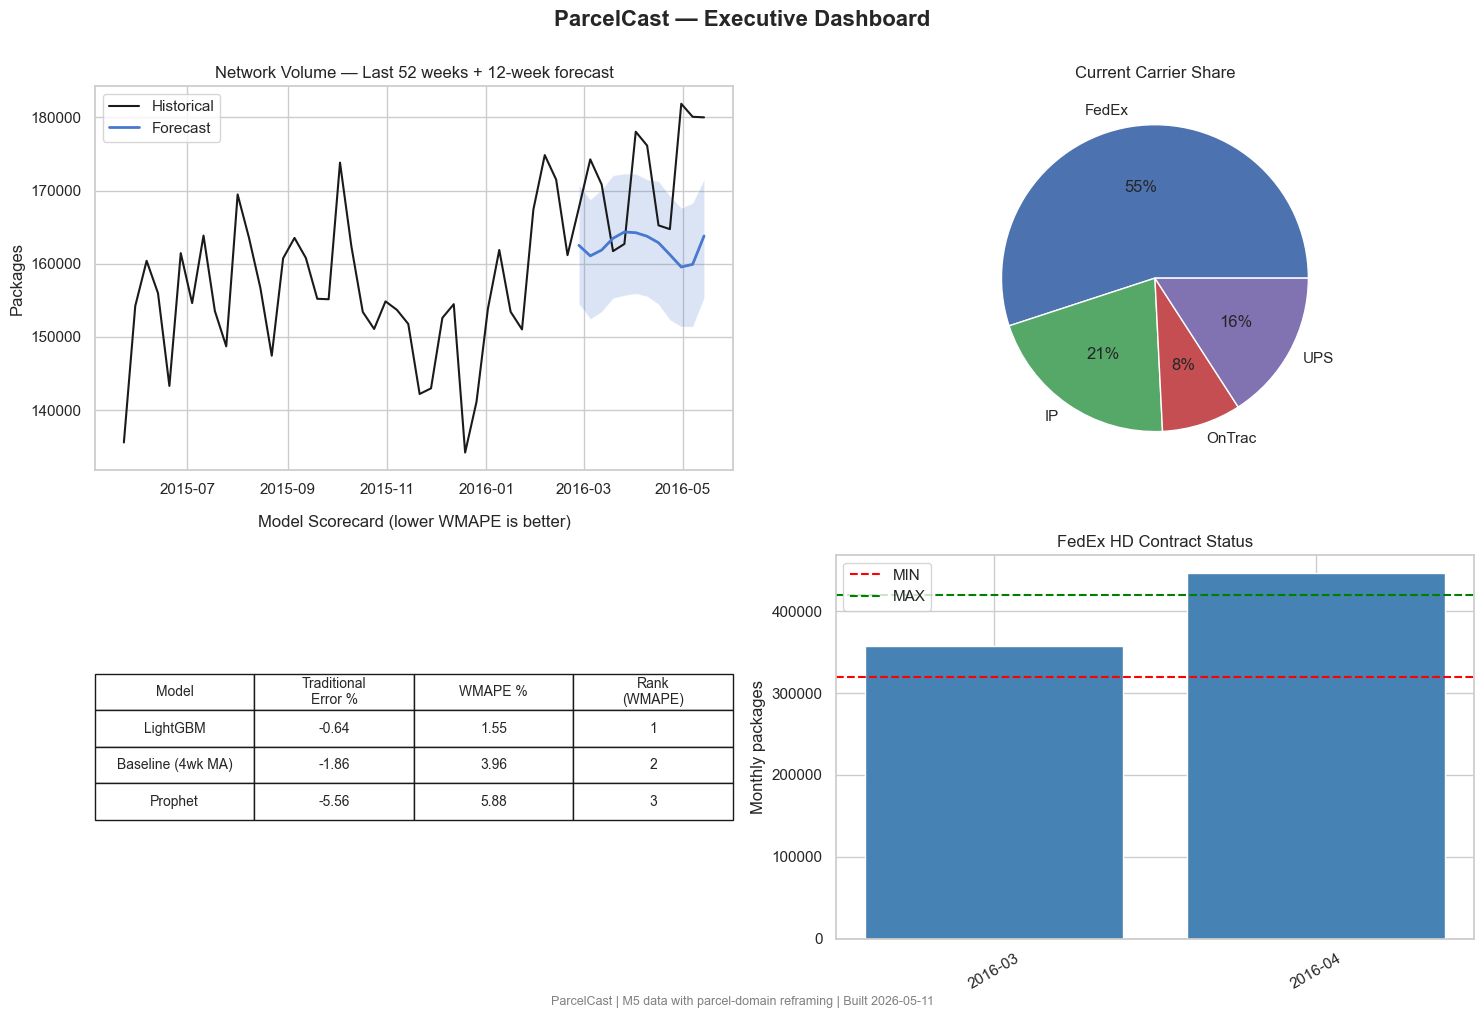

In [12]:
scorecard = pd.read_csv(DATA_DIR / "model_scorecard.csv")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("ParcelCast — Executive Dashboard", fontsize=16, fontweight="bold", y=1.0)

# Panel 1: Volume trend with forecast overlay
ax1 = axes[0, 0]
hist = (
    carrier_history.groupby("week_start", as_index=False)["carrier_packages"].sum()
    .rename(columns={"carrier_packages": "packages"})
)
ax1.plot(hist["week_start"].tail(52), hist["packages"].tail(52), "k-", label="Historical", linewidth=1.5)
ax1.plot(forecast["week_start"], forecast["packages_forecast"], "b-", label="Forecast", linewidth=2)
ax1.fill_between(forecast["week_start"], forecast["packages_low"], forecast["packages_high"], alpha=0.2)
ax1.set_title("Network Volume — Last 52 weeks + 12-week forecast")
ax1.set_ylabel("Packages")
ax1.legend()

# Panel 2: Carrier share
ax2 = axes[0, 1]
share_data = pd.Series(latest_volumes) / sum(latest_volumes.values())
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
ax2.pie(share_data.values, labels=share_data.index, autopct="%1.0f%%", colors=colors)
ax2.set_title("Current Carrier Share")

# Panel 3: Model scorecard
ax3 = axes[1, 0]
ax3.axis("off")
scorecard_display = scorecard.copy()
for c in ["traditional_error_pct", "wmape_pct"]:
    if c in scorecard_display.columns:
        scorecard_display[c] = scorecard_display[c].astype(float).round(2)
# Wrap long column headers onto two lines so they fit the table cells
header_labels = {
    "model": "Model",
    "traditional_error_pct": "Traditional\nError %",
    "wmape_pct": "WMAPE %",
    "rank_wmape": "Rank\n(WMAPE)",
}
col_labels = [header_labels.get(c, c) for c in scorecard_display.columns]
table = ax3.table(
    cellText=scorecard_display.values,
    colLabels=col_labels,
    cellLoc="center", loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax3.set_title("Model Scorecard (lower WMAPE is better)", pad=20)

# Panel 4: FedEx contract status
ax4 = axes[1, 1]
ax4.bar(fedex_status["month"], fedex_status["forecast_packages"], color="steelblue")
ax4.axhline(FEDEX_HD_CONTRACT_MIN_MONTHLY_PACKAGES, color="red", linestyle="--", label="MIN")
ax4.axhline(FEDEX_HD_CONTRACT_MAX_MONTHLY_PACKAGES, color="green", linestyle="--", label="MAX")
ax4.set_title("FedEx HD Contract Status")
ax4.set_ylabel("Monthly packages")
ax4.legend()
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=30)

fig.tight_layout()
fig.text(
    0.5, 0.005,
    f"ParcelCast | M5 data with parcel-domain reframing | "
    f"Built {pd.Timestamp.today().date().isoformat()}",
    ha="center", fontsize=9, color="gray",
)
fig.savefig(PRESENTATION_DIR / "09_executive_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## ✅ Done

Notebook 3 produced 2 artifacts in `data/` and 3 charts in `presentation/`,
bringing the project total to 14 reproducible artifacts ready for the deck.

In [13]:
print("=" * 60)
print("✅ Notebook 3 complete — full pipeline produced:")
print("=" * 60)
print("data/         fedex_contract_status.csv, cost_optimization.csv")
print("presentation/ 07_fedex_contract.png, 08_ontrac_alert.png,")
print("              09_executive_dashboard.png")
print()
above_max = (fedex_status["status"] == "ABOVE MAXIMUM").sum()
print(f"FedEx alerts: {above_max} month(s) flagged ABOVE MAXIMUM")
print(f"OnTrac:       breach week = {alert['breach_week']}")
weekly_savings = cost_scenarios["savings_$"].iloc[1]
annual_savings = cost_scenarios["annualized_savings_$"].iloc[1]
print(f"Cost shift:   ${weekly_savings:,.0f}/week → ${annual_savings:,.0f}/year")

✅ Notebook 3 complete — full pipeline produced:
data/         fedex_contract_status.csv, cost_optimization.csv
presentation/ 07_fedex_contract.png, 08_ontrac_alert.png,
              09_executive_dashboard.png

FedEx alerts: 1 month(s) flagged ABOVE MAXIMUM
OnTrac:       breach week = 2016-05-07
Cost shift:   $14,398/week → $748,696/year
